In [1]:
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterstats import zonal_stats
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1: Load Panchayat Shapefile
# ─────────────────────────────────────────────
panchayats = gpd.read_file(r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp")

# Raster paths
ghsl_10m_path = r"D:\MPLAN\thesis\objective 2\Extract_GHS_21.tif"
height_path = r"D:\MPLAN\thesis\objective 2\Extract_HEIGHT1.tif"

# Output resampled raster
ghsl_100m_path = r"D:\MPLAN\thesis\objective 2\ghsl_100m.tif"

# ─────────────────────────────────────────────
# STEP 2: Match CRS with raster
# ─────────────────────────────────────────────
with rasterio.open(ghsl_10m_path) as src:
    raster_crs = src.crs

panchayats = panchayats.to_crs(raster_crs)

# ─────────────────────────────────────────────
# STEP 3: Resample GHSL (10m → 100m)
# ─────────────────────────────────────────────
with rasterio.open(ghsl_10m_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, src.crs,
        src.width, src.height,
        *src.bounds,
        resolution=100  # target resolution
    )

    kwargs = src.meta.copy()
    kwargs.update({
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(ghsl_100m_path, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=src.crs,
            resampling=Resampling.average  # IMPORTANT
        )

print("✅ Resampling completed")

# ─────────────────────────────────────────────
# STEP 4: Zonal Statistics (Built-up)
# ─────────────────────────────────────────────
stats = zonal_stats(
    panchayats,
    ghsl_100m_path,
    stats=['mean', 'sum', 'count', 'max'],
    all_touched=True,
    nodata=None
)

stats_df = pd.DataFrame(stats)

# Add to GeoDataFrame
panchayats['ghsl_mean_pct'] = stats_df['mean'].fillna(0).round(2)
panchayats['ghsl_sum'] = stats_df['sum'].fillna(0).round(0)
panchayats['ghsl_pixel_count'] = stats_df['count'].fillna(0)
panchayats['ghsl_max_pct'] = stats_df['max'].fillna(0)

# Convert to fraction (0–1)
panchayats['ghsl_built_frac'] = (
    panchayats['ghsl_mean_pct'] / 100
).round(4)

print(panchayats['ghsl_built_frac'].describe())

# ─────────────────────────────────────────────
# STEP 5: Zonal Statistics (Height)
# ─────────────────────────────────────────────
h_stats = zonal_stats(
    panchayats,
    height_path,
    stats=['mean'],
    all_touched=True,
    nodata=None
)

panchayats['ghsl_mean_height_m'] = (
    pd.DataFrame(h_stats)['mean']
    .fillna(0)
    .round(1)
)

# ─────────────────────────────────────────────
# STEP 6: Export Results
# ─────────────────────────────────────────────
output_csv = r"D:\MPLAN\thesis\objective 2\kerala_ghsl_indicators.csv"

panchayats[[
    'LB_CODE',
    'PANCHAYAT_NAME',
    'DISTRICT',
    'ghsl_built_frac',
    'ghsl_mean_pct',
    'ghsl_sum',
    'ghsl_mean_height_m'
]].to_csv(output_csv, index=False)

print("✅ CSV Exported Successfully")

ModuleNotFoundError: No module named 'geopandas'

In [2]:
!pip install geopandas rasterio rasterstats

   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
    --------------------------------------- 0.5/30.1 MB 5.1 MB/s eta 0:00:06
   -- ------------------------------------- 1.8/30.1 MB 4.3 MB/s eta 0:00:07
   ---- ----------------------------------- 3.1/30.1 MB 5.1 MB/s eta 0:00:06
   ----- ---------------------------------- 4.2/30.1 MB 5.1 MB/s eta 0:00:06
   ------ --------------------------------- 5.2/30.1 MB 5.2 MB/s eta 0:00:05
   -------- ------------------------------- 6.3/30.1 MB 5.2 MB/s eta 0:00:05
   --------- ------------------------------ 7.1/30.1 MB 5.0 MB/s eta 0:00:05
   ----------- ---------------------------- 8.7/30.1 MB 5.2 MB/s eta 0:00:05
   ------------ --------------------------- 9.7/30.1 MB 5.2 MB/s eta 0:00:04
   -------------- ------------------------- 10.7/30.1 MB 5.2 MB/s eta 0:00:04
   --------------- ------------------------ 11.8/30.1 MB 5.2 MB/s eta 0:00:04
   ----------------- ---------------------- 13.1/30.1 MB 5.3 MB/s eta 0:00:04
   

In [7]:
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterstats import zonal_stats
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1: Load Panchayat Shapefile
# ─────────────────────────────────────────────
panchayats = gpd.read_file(r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp")

# Raster paths
ghsl_10m_path = r"D:\MPLAN\thesis\objective 2\Extract_GHS_21.tif"
height_path = r"D:\MPLAN\thesis\objective 2\Extract_HEIGHT1.tif"

# Output resampled raster
ghsl_100m_path = r"D:\MPLAN\thesis\objective 2\ghsl_100m.tif"

# ─────────────────────────────────────────────
# STEP 2: Match CRS with raster
# ─────────────────────────────────────────────
with rasterio.open(ghsl_10m_path) as src:
    raster_crs = src.crs

panchayats = panchayats.to_crs(raster_crs)

# ─────────────────────────────────────────────
# STEP 3: Resample GHSL (10m → 100m)
# ─────────────────────────────────────────────
with rasterio.open(ghsl_10m_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, src.crs,
        src.width, src.height,
        *src.bounds,
        resolution=100  # target resolution
    )

    kwargs = src.meta.copy()
    kwargs.update({
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(ghsl_100m_path, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=src.crs,
            resampling=Resampling.average  # IMPORTANT
        )

print("✅ Resampling completed")

# ─────────────────────────────────────────────
# STEP 4: Zonal Statistics (Built-up)
# ─────────────────────────────────────────────
stats = zonal_stats(
    panchayats,
    ghsl_100m_path,
    stats=['mean', 'sum', 'count', 'max'],
    all_touched=True,
    nodata=None
)

stats_df = pd.DataFrame(stats)

# Add to GeoDataFrame
panchayats['ghsl_mean_pct'] = stats_df['mean'].fillna(0).round(2)
panchayats['ghsl_sum'] = stats_df['sum'].fillna(0).round(0)
panchayats['ghsl_pixel_count'] = stats_df['count'].fillna(0)
panchayats['ghsl_max_pct'] = stats_df['max'].fillna(0)

# Convert to fraction (0–1)
panchayats['ghsl_built_frac'] = (
    panchayats['ghsl_mean_pct'] / 100
).round(4)

print(panchayats['ghsl_built_frac'].describe())

# ─────────────────────────────────────────────
# STEP 5: Zonal Statistics (Height)
# ─────────────────────────────────────────────
h_stats = zonal_stats(
    panchayats,
    height_path,
    stats=['mean'],
    all_touched=True,
    nodata=None
)

panchayats['ghsl_mean_height_m'] = (
    pd.to_numeric(pd.DataFrame(h_stats)['mean'], errors='coerce')
    .round(1)
)

# ─────────────────────────────────────────────
# STEP 6: Export Results
# ─────────────────────────────────────────────
output_csv = r"D:\MPLAN\thesis\objective 2\kerala_ghsl_indicators.csv"

panchayats[[
    'Name_1',
    'ghsl_built_frac',
    'ghsl_mean_pct',
    'ghsl_sum',
    'ghsl_mean_height_m'
]].to_csv(output_csv, index=False)

print("✅ CSV Exported Successfully")

✅ Resampling completed
count    1034.000000
mean        0.042563
std         0.038294
min         0.000300
25%         0.016700
50%         0.031900
75%         0.056975
max         0.333200
Name: ghsl_built_frac, dtype: float64
✅ CSV Exported Successfully


In [9]:
mean_height = panchayats['ghsl_mean_height_m'].dropna().mean()
print("Mean building height:", round(mean_height, 2))
mean_height = panchayats.loc[
    panchayats['ghsl_mean_height_m'] != -9999,
    'ghsl_mean_height_m'
].mean()

print("Mean building height:", round(mean_height, 2))
print(panchayats['ghsl_mean_height_m'].describe())

Mean building height: nan
Mean building height: nan
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ghsl_mean_height_m, dtype: float64


In [12]:
height_path = r"D:\MPLAN\thesis\objective 2\Extract_HEIGHT1.tif"
h_stats = zonal_stats(
    panchayats,
    height_path,
    stats=['mean'],
    all_touched=True,
    nodata=None
)

panchayats['ghsl_mean_height_m'] = (
    pd.to_numeric(pd.DataFrame(h_stats)['mean'], errors='coerce')
    .round(1)
)
print(panchayats['ghsl_mean_height_m'].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ghsl_mean_height_m, dtype: float64


Raster CRS: ESRI:54009
Min: -3.402823e+38 Max: 21.450638


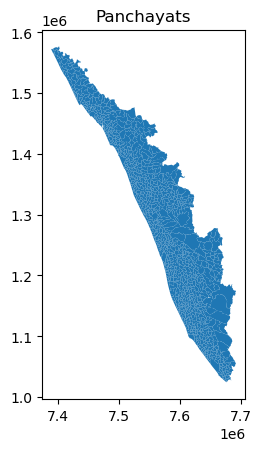

[{'mean': 1.2659625942277746}, {'mean': 0.2899258668226408}, {'mean': 0.1921519394686743}, {'mean': 0.3331141457628848}, {'mean': 1.1401709572049974}]
count    1034.000000
mean        0.192505
std         0.322453
min         0.000000
25%         0.040000
50%         0.090000
75%         0.200000
max         3.450000
Name: ghsl_mean_height_m, dtype: float64
✅ Excel file exported successfully


In [20]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1: Define raster path
# ─────────────────────────────────────────────
height_path = r"D:\MPLAN\thesis\objective 2\Extract_HEIGHT1.tif"

# ─────────────────────────────────────────────
# STEP 2: Read raster CRS + nodata
# ─────────────────────────────────────────────
with rasterio.open(height_path) as src:
    print("Raster CRS:", src.crs)
    nodata_val = src.nodata
    data = src.read(1)
    print("Min:", data.min(), "Max:", data.max())

# ─────────────────────────────────────────────
# STEP 3: Match CRS
# ─────────────────────────────────────────────
panchayats = panchayats.to_crs(src.crs)

# ─────────────────────────────────────────────
# STEP 4: Plot Panchayats (check alignment)
# ─────────────────────────────────────────────
panchayats.plot()
plt.title("Panchayats")
plt.show()

# ─────────────────────────────────────────────
# STEP 5: Zonal Statistics (Height)
# ─────────────────────────────────────────────
h_stats = zonal_stats(
    panchayats,
    height_path,
    stats=['mean'],
    all_touched=True,
    nodata=nodata_val   # ✅ correct handling
)

# Check output
print(h_stats[:5])

# ─────────────────────────────────────────────
# STEP 6: Convert to numeric safely
# ─────────────────────────────────────────────
panchayats['ghsl_mean_height_m'] = (
    pd.to_numeric(pd.DataFrame(h_stats)['mean'], errors='coerce')
    .round(2)
)

# Summary stats
print(panchayats['ghsl_mean_height_m'].describe())
output_excel = r"D:\MPLAN\thesis\objective 2\kerala_height_results.xlsx"

panchayats.to_excel(output_excel, index=False)

print("✅ Excel file exported successfully")


In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 1. Load your CSV ──
df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_panchayat_VIIRS_NTL_fixed.csv")

print(f"Total panchayats: {len(df)}")
print(f"\nRaw ntl_2022_mean statistics:")
print(df['ntl_2022_mean'].describe().round(3))

# ── 2. Check for nulls ──
print(f"\nNull values: {df['ntl_2022_mean'].isna().sum()}")
df['ntl_2022_mean'] = df['ntl_2022_mean'].fillna(0)
df['ntl_2020_mean'] = df['ntl_2020_mean'].fillna(0)

# ── 3. Log-transform — CRITICAL for skewed distribution ──
df['ntl_log_2022'] = np.log1p(df['ntl_2022_mean'])
df['ntl_log_2020'] = np.log1p(df['ntl_2020_mean'])

# ── 4. Temporal change 2020 → 2022 ──
df['ntl_change'] = df['ntl_log_2022'] - df['ntl_log_2020']

print(f"\nAfter log-transform:")
print(df['ntl_log_2022'].describe().round(3))

# ── 5. Min-max normalise ──
scaler = MinMaxScaler()
df['ntl_norm'] = scaler.fit_transform(df[['ntl_log_2022']]).round(4)

print(f"\nAfter normalisation (0-1):")
print(df['ntl_norm'].describe().round(3))

# ── 6. See top and bottom 10 panchayats ──
print("\nTop 10 highest economic intensity:")
print(df.nlargest(10, 'ntl_norm')[['Name_1','ntl_2022_mean','ntl_norm']]
      .to_string(index=False))

print("\nBottom 10 lowest economic intensity:")
print(df.nsmallest(10, 'ntl_norm')[['Name_1','ntl_2022_mean','ntl_norm']]
      .to_string(index=False))

output_path = r"D:\MPLAN\thesis\objective 2\kerala_VIIRS_processed.csv"

df.to_csv(output_path, index=False)

print("File saved at:", output_path)

Total panchayats: 1034

Raw ntl_2022_mean statistics:
count    1034.000
mean        1.522
std         1.437
min         0.274
25%         0.762
50%         1.210
75%         1.764
max        20.033
Name: ntl_2022_mean, dtype: float64

Null values: 0

After log-transform:
count    1034.000
mean        0.839
std         0.374
min         0.242
25%         0.566
50%         0.793
75%         1.017
max         3.046
Name: ntl_log_2022, dtype: float64

After normalisation (0-1):
count    1034.000
mean        0.213
std         0.133
min         0.000
25%         0.116
50%         0.196
75%         0.276
max         1.000
Name: ntl_norm, dtype: float64

Top 10 highest economic intensity:
               Name_1  ntl_2022_mean  ntl_norm
Vadavukode-Puthencruz      20.032896    1.0000
                Kochi      15.745068    0.9187
         Thrikkakkara      15.357541    0.9103
       Thrippunithura      11.142428    0.8041
                Aluva      10.216856    0.7758
          Kalamassery      1

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 1. Load Census PCA Excel ──
# Try sheet index 0 first; some files have multiple sheets
file_paths = [
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3201_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3202_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3203_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3204_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3205_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3206_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3207_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3208_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3209_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3210_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3211_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3212_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3213_2011_MDDS with UI.xlsx",
    r"D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3214_2011_MDDS with UI.xlsx"
]
df_list = [pd.read_excel(file) for file in file_paths]

df = pd.concat(df_list, ignore_index=True)

print(df.shape)
print(df.head())

# ── 2. Check column names ──
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head(3))

# ── 3. Filter to village/panchayat level rows only ──
# Column names vary slightly — adjust based on what you see in step 2
df = df[df['Level'] == 'Village'].copy()
# OR if column is named differently:
# df = df[df['TRU'] == 'Total'].copy()

print(f"\nPanchayat rows after filter: {len(df)}")

# ── 4. Select and rename relevant columns ──
# Adjust these names to match your actual Excel column headers
df = df[[
    'Name',                                    # panchayat name
    'District',                                # district
    'TehsilName',                              # taluk (optional)
    'Main_Workers_Total_Persons',              # total main workers
    'Main_Workers_Agricultural_Labourers_Persons',   # agri labourers
    'Main_Workers_Cultivators_Persons',              # cultivators
    'Main_Workers_Non_Agricultural_Persons'          # non-agri workers
]].copy()

# ── 5. Handle zeros and nulls ──
df['Main_Workers_Total_Persons'] = pd.to_numeric(
    df['Main_Workers_Total_Persons'], errors='coerce').fillna(0)
df['Main_Workers_Non_Agricultural_Persons'] = pd.to_numeric(
    df['Main_Workers_Non_Agricultural_Persons'], errors='coerce').fillna(0)

# ── 6. Compute non-agricultural share ──
df['nonagri_share'] = np.where(
    df['Main_Workers_Total_Persons'] > 0,
    df['Main_Workers_Non_Agricultural_Persons'] /
    df['Main_Workers_Total_Persons'],
    0
).round(4)

print("\nNon-agri share statistics:")
print(df['nonagri_share'].describe().round(3))

# ── 7. Normalise to 0-1 ──
scaler = MinMaxScaler()
df['nonagri_norm'] = scaler.fit_transform(
    df[['nonagri_share']]
).round(4)

# ── 8. Check top and bottom results ──
print("\nTop 10 — most non-agricultural:")
print(df.nlargest(10, 'nonagri_norm')[['Name','nonagri_share','nonagri_norm']]
      .to_string(index=False))

print("\nBottom 10 — most agricultural:")
print(df.nsmallest(10, 'nonagri_norm')[['Name','nonagri_share','nonagri_norm']]
      .to_string(index=False))

# ── 9. Save ──
df.to_csv('kerala_nonagri_workforce.csv', index=False)
print("\nSaved: kerala_nonagri_workforce.csv")

Columns: ['State', 'District', 'Subdistt', 'Town/Village', 'Ward', 'EB', 'Level', 'Name', 'TRU', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06', 'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT', 'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M', 'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P', 'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F', 'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M', 'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P', 'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F', 'MARG_HH_P', 'MARG_HH_M', 'MARG_HH_F', 'MARG_OT_P', 'MARG_OT_M', 'MARG_OT_F', 'MARGWORK_3_6_P', 'MARGWORK_3_6_M', 'MARGWORK_3_6_F', 'MARG_CL_3_6_P', 'MARG_CL_3_6_M', 'MARG_CL_3_6_F', 'MARG_AL_3_6_P', 'MARG_AL_3_6_M', 'MARG_AL_3_6_F', 'MARG_HH_3_6_P', 'MARG_HH_3_6_M', 'MARG_HH_3_6_F', 'MARG_OT_3_6_P', 'MARG_OT_3_6_M', 'MARG_OT_3_6_F', 'MARGWORK_0_3_P', 'MARGWORK_0_3_M', 'MARGWORK

KeyError: "['TehsilName', 'Main_Workers_Total_Persons', 'Main_Workers_Agricultural_Labourers_Persons', 'Main_Workers_Cultivators_Persons', 'Main_Workers_Non_Agricultural_Persons'] not in index"

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import glob
import os

# ── 1. Read multiple Excel files (exclude temp files) ──
files = glob.glob(r'D:\MPLAN\thesis\objective 2\non-agri_workers\*.xlsx')

# Remove files starting with '~$'
files = [f for f in files if not os.path.basename(f).startswith('~$')]

print("Files being read:")
for f in files:
    print(f)

df_list = []

for file in files:
    try:
        temp = pd.read_excel(file, sheet_name=0)
        df_list.append(temp)
    except Exception as e:
        print(f"Skipping {file} due to error: {e}")

# Combine all files
df = pd.concat(df_list, ignore_index=True)

print("\nCombined Shape:", df.shape)

# ── 2. Select required columns ──
df = df[[
    'Name',          # adjust if needed
    'District',      # adjust if needed
    'MAINWORK_P',
    'MAIN_OT_P'
]].copy()

# ── 3. Convert to numeric ──
for col in ['MAINWORK_P', 'MAIN_OT_P']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ── 4. Compute non-agri share ──
df['nonagri_share'] = np.where(
    df['MAINWORK_P'] > 0,
    df['MAIN_OT_P'] / df['MAINWORK_P'],
    0
).round(4)

# ── 5. Normalize ──
scaler = MinMaxScaler()
df['nonagri_norm'] = scaler.fit_transform(df[['nonagri_share']]).round(4)

# ── 6. Save ──
df.to_csv(r'D:\MPLAN\thesis\objective 2\non-agri_workers\kerala_nonagri_all.csv', index=False)

print("\n✅ Done! File saved.")

Files being read:
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3201_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3202_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3203_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3204_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3205_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3206_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3207_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3208_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3209_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3210_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3211_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\objective 2\non-agri_workers\DDW_PCA3212_2011_MDDS with UI.xlsx
D:\MPLAN\thesis\object

In [40]:
import pandas as pd
import geopandas as gpd

# ── 1. Load shapefile ──
shp_path = r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp"
gdf = gpd.read_file(shp_path)

print("Shapefile columns:", gdf.columns)

# ── 2. Load CSV ──
csv_path = r"D:\MPLAN\thesis\objective 2\non-agri_workers\kerala_nonagri_all.csv"
df = pd.read_csv(csv_path)

print("CSV columns:", df.columns)

gdf['name_clean'] = gdf['Name_1'].str.lower().str.strip().str.replace(' ', '')
df['name_clean'] = df['Name'].str.lower().str.strip().str.replace(' ', '')

# Merge
merged = gdf.merge(df, on='name_clean', how='inner')

print(merged.columns.tolist())
merged[[
    'Name_1',        # shapefile name
    'Name_x',        # one Name column
    'Name_y',        # other Name column
    'District',
    'nonagri_share',
    'nonagri_norm'
]].to_csv(
    r'D:\MPLAN\thesis\comparison_lsgd_nonagri.csv',
    index=False
)

print("✅ DONE — no errors now")

Shapefile columns: Index(['name_ml', 'Name_1', 'AREA', 'Name', 'CRZ_Zone_1', 'Value', 'OBJECTID',
       'FID_1', 'LSG', 'SLR', 'ESA', 'F_COA_ERO', 'FLOOD', 'LANDSLIDE',
       'DROUGHT', 'CRZ', 'Cluster_4', 'Cluster_5', 'Cluster_6', 'Cluster',
       'geometry'],
      dtype='object')
CSV columns: Index(['Name', 'District', 'MAINWORK_P', 'MAIN_OT_P', 'nonagri_share',
       'nonagri_norm'],
      dtype='object')
['name_ml', 'Name_1', 'AREA', 'Name_x', 'CRZ_Zone_1', 'Value', 'OBJECTID', 'FID_1', 'LSG', 'SLR', 'ESA', 'F_COA_ERO', 'FLOOD', 'LANDSLIDE', 'DROUGHT', 'CRZ', 'Cluster_4', 'Cluster_5', 'Cluster_6', 'Cluster', 'geometry', 'name_clean', 'Name_y', 'District', 'MAINWORK_P', 'MAIN_OT_P', 'nonagri_share', 'nonagri_norm']
✅ DONE — no errors now


In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 1. Load Census PCA Excel ──
# Try sheet index 0 first; some files have multiple sheets
df = pd.read_excel(r"D:\MPLAN\thesis\objective 2\non-agri_workers\data_clean.xlsx")


# ── 4. Select and rename relevant columns ──
# Adjust these names to match your actual Excel column headers
df = df[[
    'Name',                                    # panchayat name
    'MAINWORK_P',              # total main workers
    'MAIN_OT_P'          # non-agri workers
]].copy()

# ── 5. Handle zeros and nulls ──
df['MAINWORK_P'] = pd.to_numeric(
    df['MAINWORK_P'], errors='coerce').fillna(0)
df['MAIN_OT_P'] = pd.to_numeric(
    df['MAIN_OT_P'], errors='coerce').fillna(0)

# ── 6. Compute non-agricultural share ──
df['nonagri_share'] = np.where(
    df['MAINWORK_P'] > 0,
    df['MAIN_OT_P'] /
    df['MAINWORK_P'],
    0
).round(4)

print("\nNon-agri share statistics:")
print(df['nonagri_share'].describe().round(3))

# ── 7. Normalise to 0-1 ──
scaler = MinMaxScaler()
df['nonagri_norm'] = scaler.fit_transform(
    df[['nonagri_share']]
).round(4)

# ── 8. Check top and bottom results ──
print("\nTop 10 — most non-agricultural:")
print(df.nlargest(10, 'nonagri_norm')[['Name','nonagri_share','nonagri_norm']]
      .to_string(index=False))

print("\nBottom 10 — most agricultural:")
print(df.nsmallest(10, 'nonagri_norm')[['Name','nonagri_share','nonagri_norm']]
      .to_string(index=False))

# ── 9. Save ──
df.to_csv(r'D:\MPLAN\thesis\objective 2\non-agri_workers\kerala_nonagri_final.csv', index=False)
print("\nSaved: kerala_nonagri_workforce.csv")


Non-agri share statistics:
count    1551.000
mean        0.789
std         0.155
min         0.000
25%         0.722
50%         0.819
75%         0.906
max         1.000
Name: nonagri_share, dtype: float64

Top 10 — most non-agricultural:
                    Name  nonagri_share  nonagri_norm
  Kannur Cantonment (CB)         0.9997        1.0000
Thrikkakara North (Part)         0.9892        0.9895
          Mulavukad (CT)         0.9892        0.9895
       Valapattanam (CT)         0.9867        0.9870
              Vadavukode         0.9862        0.9865
        Cheruvannur (CT)         0.9845        0.9848
           New Mahe (CT)         0.9844        0.9847
              Kannur (M)         0.9828        0.9831
         Kumbalangy (CT)         0.9827        0.9830
            Beypore (CT)         0.9826        0.9829

Bottom 10 — most agricultural:
               Name  nonagri_share  nonagri_norm
               Name         0.0000        0.0000
Aryad South  (Part)         0.0000 

In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 1. Load the intersection CSV from QGIS ──
df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\lulc_intersection.csv")

# Check column names — adjust these to match your actual file
print("Columns:", df.columns.tolist())
print(df.head(3))

# Expected columns (names may differ — adjust below):
# 'Name_1'     → panchayat name (from your LSGD shapefile)
# 'CLASS_NAME' → LULC class (from Bhuvan)
# 'area_m2'    → area of this LULC patch in m² (computed in QGIS)

# ── 2. Rename to standard names (adjust to match yours) ──
df = df.rename(columns={
    'Name_1':     'panchayat',   # your panchayat name column
    'lulc_lulc': 'lulc_class',  # your LULC class column
    'Shape_Area':    'area'         # your area column
})

# ── 3. Clean: drop tiny slivers (< 1000 m²) from intersection artefacts ──
df = df[df['area'] > 1000].copy()

# ── 4. Aggregate — total area per panchayat per LULC class ──
agg = df.groupby(['panchayat', 'lulc_class'])['area'].sum().reset_index()
print(f"\nUnique LULC classes: {agg['lulc_class'].unique()}")
print(f"Unique panchayats: {agg['panchayat'].nunique()}")

# ── 5. Compute total area per panchayat ──
total_area = agg.groupby('panchayat')['area'].sum().reset_index()
total_area.columns = ['panchayat', 'total_area']

# ── 6. Merge and compute proportion of each class ──
agg = agg.merge(total_area, on='panchayat')
agg['proportion'] = agg['area'] / agg['total_area']

# ── 7. Compute Shannon entropy per panchayat ──
def shannon_entropy(proportions):
    # Filter out zero proportions to avoid log(0)
    p = proportions[proportions > 0]
    return -np.sum(p * np.log(p))

entropy_df = agg.groupby('panchayat')['proportion'].apply(
    shannon_entropy
).reset_index()
entropy_df.columns = ['panchayat', 'shannon_H']

# ── 8. Also compute number of distinct LULC classes per panchayat ──
class_count = agg.groupby('panchayat')['lulc_class'].nunique().reset_index()
class_count.columns = ['panchayat', 'lulc_class_count']

entropy_df = entropy_df.merge(class_count, on='panchayat')

print("\nShannon entropy statistics:")
print(entropy_df['shannon_H'].describe().round(3))

# ── 9. Check results ──
print("\nTop 10 most diverse panchayats:")
print(entropy_df.nlargest(10, 'shannon_H')[
    ['panchayat', 'shannon_H', 'lulc_class_count']
].to_string(index=False))

print("\nBottom 10 least diverse:")
print(entropy_df.nsmallest(10, 'shannon_H')[
    ['panchayat', 'shannon_H', 'lulc_class_count']
].to_string(index=False))

# ── 10. Normalise to 0–1 ──
scaler = MinMaxScaler()
entropy_df['I5_diversity'] = scaler.fit_transform(
    entropy_df[['shannon_H']]
).round(4)

# ── 11. Export ──
entropy_df.to_csv('kerala_I5_lulc_diversity.csv', index=False)
print(f"\nSaved: {len(entropy_df)} panchayats")

Columns: ['OBJECTID', 'FID_RasterT_tif2_lulc', 'RasterT_tif2_Id', 'RasterT_tif2_gridcode', 'lulc_OID', 'lulc_Value', 'lulc_Count', 'lulc_lulc', 'FID_Export_LSGD_kerala_panchayat_VIIRS_NTL_f1', 'Export_LSGD_name_ml', 'Export_LSGD_Name_1', 'Export_LSGD_AREA', 'Export_LSGD_Name', 'Export_LSGD_CRZ_Zone_1', 'Export_LSGD_Value', 'Export_LSGD_OBJECTID', 'Export_LSGD_FID_1', 'Export_LSGD_LSG', 'Export_LSGD_SLR', 'Export_LSGD_ESA', 'Export_LSGD_F_COA_ERO', 'Export_LSGD_FLOOD', 'Export_LSGD_LANDSLIDE', 'Export_LSGD_DROUGHT', 'Export_LSGD_CRZ', 'Export_LSGD_Cluster_4', 'Export_LSGD_Cluster_5', 'Export_LSGD_Cluster_6', 'Export_LSGD_Cluster', 'kerala_panchayat_VIIRS_NTL_f1_OBJECTID', 'kerala_panchayat_VIIRS_NTL_f1_Name_1', 'kerala_panchayat_VIIRS_NTL_f1_ntl_2022_mean', 'kerala_panchayat_VIIRS_NTL_f1_ntl_2022_max', 'kerala_panchayat_VIIRS_NTL_f1_ntl_2022_count', 'kerala_panchayat_VIIRS_NTL_f1_ntl_2020_mean', 'Shape_Length', 'Shape_Area']
   OBJECTID  FID_RasterT_tif2_lulc  RasterT_tif2_Id  RasterT_t

KeyError: 'panchayat'

In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 1. Load the intersection CSV from QGIS ──
df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\Intersection.csv")

# Check column names — adjust these to match your actual file
print("Columns:", df.columns.tolist())
print(df.head(3))

# Expected columns (names may differ — adjust below):
# 'Name_1'     → panchayat name (from your LSGD shapefile)
# 'CLASS_NAME' → LULC class (from Bhuvan)
# 'area_m2'    → area of this LULC patch in m² (computed in QGIS)

# ── 2. Rename to standard names (adjust to match yours) ──
df = df.rename(columns={
    'Name_1':     'panchayat',   # your panchayat name column
    'lulc_lulc': 'lulc_class',  # your LULC class column
    'SUM_area_m':    'area'         # your area column
})

# ── 3. Clean: drop tiny slivers (< 1000 m²) from intersection artefacts ──
df = df[df['area'] > 1000].copy()

# ── 4. Aggregate — total area per panchayat per LULC class ──
agg = df.groupby(['panchayat', 'lulc_class'])['area'].sum().reset_index()
print(f"\nUnique LULC classes: {agg['lulc_class'].unique()}")
print(f"Unique panchayats: {agg['panchayat'].nunique()}")

# ── 5. Compute total area per panchayat ──
total_area = agg.groupby('panchayat')['area'].sum().reset_index()
total_area.columns = ['panchayat', 'total_area']

# ── 6. Merge and compute proportion of each class ──
agg = agg.merge(total_area, on='panchayat')
agg['proportion'] = agg['area'] / agg['total_area']

# ── 7. Compute Shannon entropy per panchayat ──
def shannon_entropy(proportions):
    # Filter out zero proportions to avoid log(0)
    p = proportions[proportions > 0]
    return -np.sum(p * np.log(p))

entropy_df = agg.groupby('panchayat')['proportion'].apply(
    shannon_entropy
).reset_index()
entropy_df.columns = ['panchayat', 'shannon_H']

# ── 8. Also compute number of distinct LULC classes per panchayat ──
class_count = agg.groupby('panchayat')['lulc_class'].nunique().reset_index()
class_count.columns = ['panchayat', 'lulc_class_count']

entropy_df = entropy_df.merge(class_count, on='panchayat')

print("\nShannon entropy statistics:")
print(entropy_df['shannon_H'].describe().round(3))

# ── 9. Check results ──
print("\nTop 10 most diverse panchayats:")
print(entropy_df.nlargest(10, 'shannon_H')[
    ['panchayat', 'shannon_H', 'lulc_class_count']
].to_string(index=False))

print("\nBottom 10 least diverse:")
print(entropy_df.nsmallest(10, 'shannon_H')[
    ['panchayat', 'shannon_H', 'lulc_class_count']
].to_string(index=False))

# ── 10. Normalise to 0–1 ──
scaler = MinMaxScaler()
entropy_df['I5_diversity'] = scaler.fit_transform(
    entropy_df[['shannon_H']]
).round(4)

# ── 11. Export ──
entropy_df.to_csv(r'D:\MPLAN\thesis\objective 2\shanons_entropy.csv', index=False)
print(f"\nSaved: {len(entropy_df)} panchayats")


Columns: ['OBJECTID', 'Name_1', 'lulc_lulc', 'FREQUENCY', 'SUM_area_m']
   OBJECTID              Name_1    lulc_lulc  FREQUENCY    SUM_area_m
0         1  Abdu Rahiman Nagar  Bare ground          5  4.999991e+02
1         2  Abdu Rahiman Nagar   Built Area         10  1.305303e+07
2         3  Abdu Rahiman Nagar        Crops         27  2.023040e+06

Unique LULC classes: ['Built Area' 'Crops' 'Rangeland' 'trees' 'water' 'Bare ground'
 'flooded vegetation' 'Clouds']
Unique panchayats: 1027

Shannon entropy statistics:
count    1027.000
mean        0.754
std         0.271
min        -0.000
25%         0.601
50%         0.774
75%         0.932
max         1.437
Name: shannon_H, dtype: float64

Top 10 most diverse panchayats:
        panchayat  shannon_H  lulc_class_count
          Tavanur   1.436890                 7
   Padinharethara   1.414095                 6
            Tarur   1.408385                 5
        Pudussery   1.392087                 7
   Thiruvilwamala   1.386545     

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 1. Load CSV ──
df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\Intersection.csv")

print("Columns:", df.columns.tolist())
print(df.head(3))

# ── 2. Rename columns (adjust if needed) ──
df = df.rename(columns={
    'Name_1': 'panchayat',
    'lulc_lulc': 'lulc_class',
    'SUM_area_m': 'area'
})

# ── 3. Clean (optional) ──
df = df[df['area'] > 1000].copy()

# ── 4. Use df directly (already aggregated) ──
agg = df.copy()

# ── 5. Total area per panchayat ──
total_area = agg.groupby('panchayat')['area'].sum().reset_index()
total_area.columns = ['panchayat', 'total_area']

# ── 6. Compute proportions ──
agg = agg.merge(total_area, on='panchayat')
agg['proportion'] = agg['area'] / agg['total_area']

# ── 7. Shannon entropy ──
def shannon_entropy(proportions):
    p = proportions[proportions > 0]
    return -np.sum(p * np.log(p))

entropy_df = agg.groupby('panchayat')['proportion'].apply(
    shannon_entropy
).reset_index()

entropy_df.columns = ['panchayat', 'shannon_H']

# ── 8. Count LULC classes ──
class_count = agg.groupby('panchayat')['lulc_class'].nunique().reset_index()
class_count.columns = ['panchayat', 'lulc_class_count']

entropy_df = entropy_df.merge(class_count, on='panchayat')

# ── 9. Normalize ──
scaler = MinMaxScaler()
entropy_df['I5_diversity'] = scaler.fit_transform(
    entropy_df[['shannon_H']]
).round(4)

# ── 10. Export ──
entropy_df.to_csv(r'D:\MPLAN\thesis\objective 2\shanons_entropy.csv', index=False)

print(f"\nSaved: {len(entropy_df)} panchayats")

Columns: ['OBJECTID', 'Name_1', 'lulc_lulc', 'FREQUENCY', 'SUM_area_m']
   OBJECTID              Name_1    lulc_lulc  FREQUENCY    SUM_area_m
0         1  Abdu Rahiman Nagar  Bare ground          5  4.999991e+02
1         2  Abdu Rahiman Nagar   Built Area         10  1.305303e+07
2         3  Abdu Rahiman Nagar        Crops         27  2.023040e+06

Saved: 1027 panchayats


In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_I6.csv")

# Use only intersection density since slope is uniform
scaler = MinMaxScaler()
df['I6'] = scaler.fit_transform(df[['int_norm']]).round(4)

df.to_csv(r'D:\MPLAN\thesis\objective 2\I6.csv', index=False)


Loading indicator files...
  I1: 1034 rows
  I2: 1034 rows
  I3: 1034 rows
  I4: 1034 rows
  I5: 1034 rows
  I6: 1034 rows

Merging all indicators...
  Merged table: 1468 panchayats

Null values per indicator:
I1      0
I2      0
I3      0
I4    699
I5     17
I6      0
  I4: 699 nulls filled with median 0.4563
  I5: 17 nulls filled with median 0.5747

Indicator summary statistics:
             I1        I2        I3        I4        I5        I6
count  1468.000  1468.000  1468.000  1468.000  1468.000  1468.000
mean      0.854     0.097     0.093     0.455     0.571     0.029
std       0.148     0.083     0.060     0.069     0.180     0.058
min       0.000     0.000     0.000     0.021     0.000     0.000
25%       0.816     0.046     0.053     0.456     0.483     0.004
50%       0.901     0.076     0.077     0.456     0.575     0.012
75%       0.939     0.129     0.118     0.464     0.702     0.031
max       1.000     1.000     0.500     0.768     1.000     1.000

Computing Shannon ent

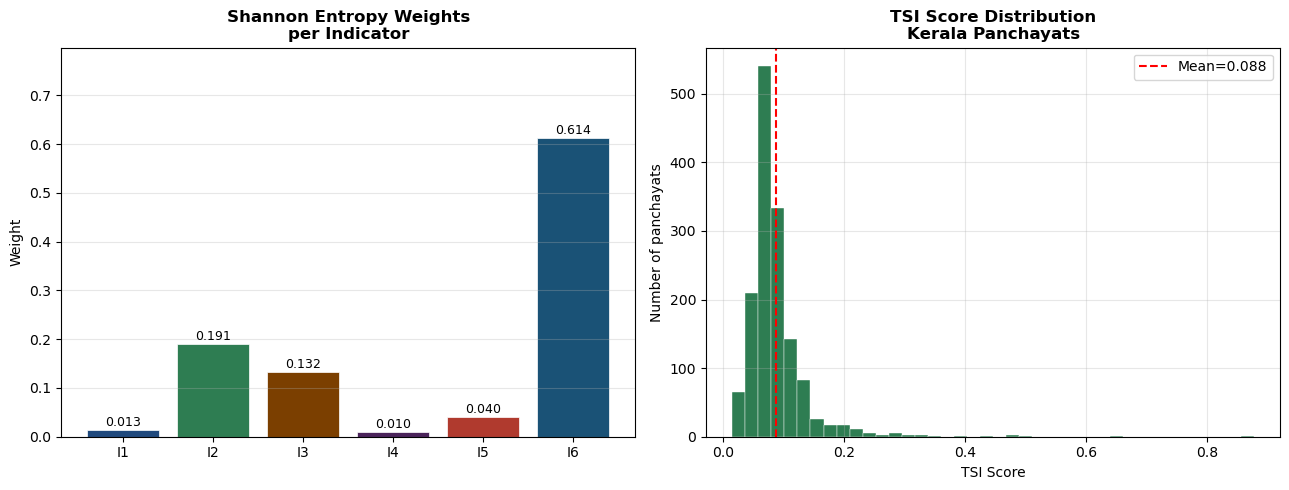

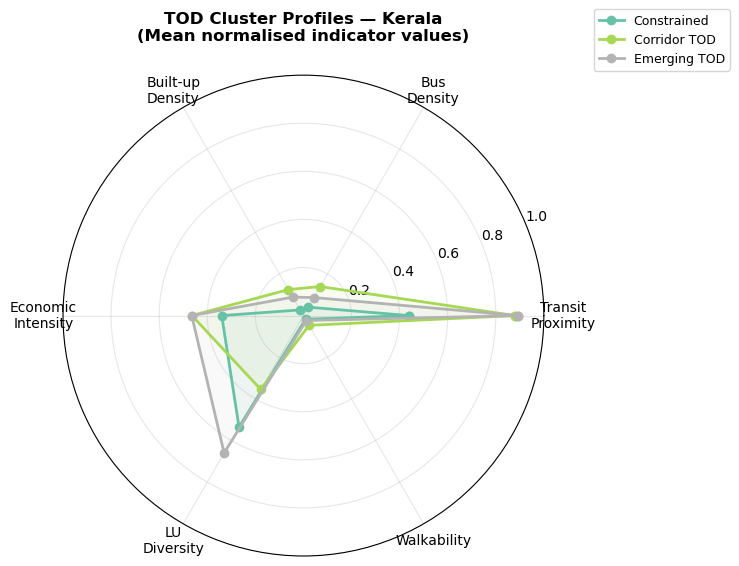

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Loading indicator files...")

# ── Load each indicator CSV ──────────────────────────────────
# Adjust column names to exactly match what you have in each file

i1 = pd.read_csv(r"D:\MPLAN\thesis\objective 2\I1.CSV")
i1 = i1[['Name_1', 'I1_norm']].rename(columns={'I1_norm': 'I1'})

i2 = pd.read_csv(r"D:\MPLAN\thesis\objective 2\I2.csv")
i2 = i2[['Name_1', 'I2_norm']].rename(columns={'I2_norm': 'I2'})

i3 = pd.read_csv(r"D:\MPLAN\thesis\objective 2\I3.csv")
i3 = i3[['Name_1', 'I3']].copy()   # already named I3

i4 = pd.read_csv(r"D:\MPLAN\thesis\objective 2\non-agri_workers\kerala_I4.csv")
i4 = i4[['Name_1', 'I4']].copy()   # already named I4

i5 = pd.read_csv(r"D:\MPLAN\thesis\objective 2\l5.csv")
i5 = i5[['Name_1', 'I5_diversity']].rename(columns={'I5_diversity': 'I5'})

i6 = pd.read_csv(r"D:\MPLAN\thesis\objective 2\I6.csv")
i6 = i6[['Name_1', 'I6']].copy()   # already named I6

print(f"  I1: {len(i1)} rows")
print(f"  I2: {len(i2)} rows")
print(f"  I3: {len(i3)} rows")
print(f"  I4: {len(i4)} rows")
print(f"  I5: {len(i5)} rows")
print(f"  I6: {len(i6)} rows")

# ── Merge all on Name_1 ──────────────────────────────────────
print("\nMerging all indicators...")

master = i1.copy()
for df, label in [(i2,'I2'),(i3,'I3'),(i4,'I4'),(i5,'I5'),(i6,'I6')]:
    master = master.merge(df[['Name_1', label]], on='Name_1', how='outer')

print(f"  Merged table: {len(master)} panchayats")

# ── Check nulls ──────────────────────────────────────────────
print("\nNull values per indicator:")
nulls = master[['I1','I2','I3','I4','I5','I6']].isnull().sum()
print(nulls.to_string())

# Fill nulls with column median
for col in ['I1','I2','I3','I4','I5','I6']:
    med = master[col].median()
    n_null = master[col].isna().sum()
    if n_null > 0:
        print(f"  {col}: {n_null} nulls filled with median {med:.4f}")
    master[col] = master[col].fillna(med).clip(0, 1)

# ── Final distribution check ─────────────────────────────────
print("\nIndicator summary statistics:")
print(master[['I1','I2','I3','I4','I5','I6']].describe().round(3).to_string())

# ══════════════════════════════════════════════════════════════
#  SHANNON ENTROPY WEIGHTING
# ══════════════════════════════════════════════════════════════
print("\nComputing Shannon entropy weights...")

ind_cols = ['I1','I2','I3','I4','I5','I6']
X = master[ind_cols].values
n, m = X.shape

# Proportion matrix
P = X / (X.sum(axis=0) + 1e-10)

# Entropy
lnP = np.where(P > 1e-10, np.log(P), 0)
E = -(1 / np.log(n)) * np.sum(P * lnP, axis=0)

# Weights
d = 1 - E
w = d / d.sum()

print("\n  ┌──────────────────────────────────────────────────┐")
print("  │  Indicator   Entropy     Divergence    Weight    │")
print("  ├──────────────────────────────────────────────────┤")
for i, col in enumerate(ind_cols):
    bar = "█" * int(w[i] * 40)
    print(f"  │  {col}         {E[i]:.4f}      {d[i]:.4f}       {w[i]:.4f}  │")
print("  ├──────────────────────────────────────────────────┤")
print(f"  │  Total       —            {d.sum():.4f}       {w.sum():.4f}  │")
print("  └──────────────────────────────────────────────────┘")

# ══════════════════════════════════════════════════════════════
#  COMPUTE TSI SCORE
# ══════════════════════════════════════════════════════════════
print("\nComputing TSI scores...")

master['TSI_score'] = (X @ w).round(4)

# Classify
master['TSI_class'] = pd.cut(
    master['TSI_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01],
    labels=['Very Low','Low','Moderate','High','Very High'],
    include_lowest=True
)

print(f"\n  TSI statistics:")
print(master['TSI_score'].describe().round(4).to_string())
print(f"\n  TSI class distribution:")
print(master['TSI_class'].value_counts().sort_index().to_string())

print(f"\n  Top 15 panchayats — highest TOD suitability:")
cols_show = ['Name_1','I1','I2','I3','I4','I5','I6','TSI_score','TSI_class']
print(master.nlargest(15,'TSI_score')[cols_show].to_string(index=False))

print(f"\n  Bottom 10 panchayats — lowest TOD suitability:")
print(master.nsmallest(10,'TSI_score')[cols_show].to_string(index=False))

# ══════════════════════════════════════════════════════════════
#  K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════════
print("\nFinding optimal number of clusters...")

sil_scores = {}
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores[k] = sil
    print(f"  k={k}  silhouette={sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n  Best k = {best_k}")

# Final clustering
km = KMeans(n_clusters=best_k, random_state=42, n_init=15)
master['cluster_id'] = km.fit_predict(X)

# Name clusters by TSI rank
tsi_means = master.groupby('cluster_id')['TSI_score'].mean().sort_values()
all_names  = ['Constrained','Emerging TOD',
              'Corridor TOD','High Potential','Primary TOD Hub']
name_map   = {cid: all_names[rank] for rank, cid in enumerate(tsi_means.index)}
master['TOD_cluster'] = master['cluster_id'].map(name_map)

print(f"\n  Cluster profiles:")
profile = master.groupby('TOD_cluster')[ind_cols+['TSI_score']].mean().round(3)
print(profile.to_string())

print(f"\n  Cluster counts:")
print(master['TOD_cluster'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
#  EXPORT
# ══════════════════════════════════════════════════════════════
print("\nExporting results...")

out_cols = ['Name_1','I1','I2','I3','I4','I5','I6',
            'TSI_score','TSI_class','TOD_cluster','cluster_id']
master[out_cols].to_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_final1.csv", index=False)
print("  Saved: kerala_TSI_final.csv")

# Join to shapefile
try:
    gdf = gpd.read_file(r"D:\MPLAN\thesis\objective 2\LSGD_shapefile").to_crs('EPSG:32643')
    gdf_out = gdf.merge(master[out_cols], on='Name_1', how='left')
    gdf_out.to_file('kerala_TOD_suitability_final.gpkg', driver='GPKG')
    print("  Saved: kerala_TOD_suitability_final.gpkg")
except Exception as e:
    print(f"  Shapefile export skipped ({e})")
    print("  Join kerala_TSI_final.csv to LSGD.shp manually in ArcGIS")

# ══════════════════════════════════════════════════════════════
#  PLOTS
# ══════════════════════════════════════════════════════════════

# -- Weight bar chart --
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#1F497D','#2E7D52','#7B3F00','#4A235A','#B03A2E','#1A5276']
bars = axes[0].bar(ind_cols, w, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Shannon Entropy Weights\nper Indicator', fontweight='bold')
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, max(w) * 1.3)
for bar, weight in zip(bars, w):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{weight:.3f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# -- TSI histogram --
axes[1].hist(master['TSI_score'], bins=40,
             color='#2E7D52', edgecolor='white', linewidth=0.3)
axes[1].set_title('TSI Score Distribution\nKerala Panchayats', fontweight='bold')
axes[1].set_xlabel('TSI Score')
axes[1].set_ylabel('Number of panchayats')
axes[1].axvline(master['TSI_score'].mean(), color='red',
                linestyle='--', label=f"Mean={master['TSI_score'].mean():.3f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('TSI_weights_and_distribution.png', dpi=150, bbox_inches='tight')
print("  Saved: TSI_weights_and_distribution.png")

# -- Radar chart of cluster profiles --
categories = ['Transit\nProximity','Bus\nDensity','Built-up\nDensity',
              'Economic\nIntensity','LU\nDiversity','Walkability']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = plt.cm.Set2(np.linspace(0, 1, best_k))

for i, (name, group) in enumerate(
    master.groupby('TOD_cluster')[ind_cols].mean().iterrows()
):
    vals = group.tolist() + [group.tolist()[0]]
    ax.plot(angles, vals, 'o-', lw=2, color=palette[i], label=name)
    ax.fill(angles, vals, alpha=0.08, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title('TOD Cluster Profiles — Kerala\n(Mean normalised indicator values)',
             size=12, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\objective 2\cluster_radar_chart.png", dpi=150, bbox_inches='tight')
print("  Saved: cluster_radar_chart.png")

print("\n" + "="*55)
print("  COMPLETE")
print(f"  {len(master)} panchayats | {best_k} TOD clusters")
print("  Next: join kerala_TSI_final.csv to ArcGIS shapefile")
print("  Then: produce TSI map + cluster map")
print("="*55)

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

master = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_final1.csv")
ind_cols = ['I1','I2','I3','I4','I5','I6']
X = master[ind_cols].fillna(0).values

# ── Option 1: Cap I6 weight and redistribute ──────────────────
# Recompute entropy but cap any single indicator at max weight 0.25
n, m = X.shape
P    = X / (X.sum(axis=0) + 1e-10)
lnP  = np.where(P > 1e-10, np.log(P), 0)
E    = -(1/np.log(n)) * np.sum(P * lnP, axis=0)
d    = 1 - E
w    = d / d.sum()

print("Original weights:", dict(zip(ind_cols, w.round(3))))

# Cap I6 at 0.25 and redistribute surplus to I1 and I4
w_capped = w.copy()
surplus   = max(0, w_capped[5] - 0.25)
w_capped[5] = 0.25
# Give surplus equally to I1 (transit) and I4 (economic) — most theoretically important
w_capped[0] += surplus * 0.5
w_capped[3] += surplus * 0.5
w_capped = w_capped / w_capped.sum()   # renormalise to sum = 1

print("Capped weights:   ", dict(zip(ind_cols, w_capped.round(3))))

# ── Option 2: Equal weights (robustness check) ────────────────
w_equal = np.array([1/6]*6)
print("Equal weights:    ", dict(zip(ind_cols, w_equal.round(3))))

# ── Recompute TSI with both weight sets ───────────────────────
master['TSI_capped'] = (X @ w_capped).round(4)
master['TSI_equal']  = (X @ w_equal ).round(4)

print("\nTSI capped stats:")
print(master['TSI_capped'].describe().round(3))

print("\nTSI equal stats:")
print(master['TSI_equal'].describe().round(3))

# ── Use capped version as final TSI ──────────────────────────
master['TSI_score'] = master['TSI_capped']

master.to_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_corrected.csv", index=False)
print("\nSaved: kerala_TSI_corrected.csv")
print("Re-run clustering on TSI_score column")

Original weights: {'I1': np.float64(0.013), 'I2': np.float64(0.191), 'I3': np.float64(0.132), 'I4': np.float64(0.01), 'I5': np.float64(0.04), 'I6': np.float64(0.614)}
Capped weights:    {'I1': np.float64(0.195), 'I2': np.float64(0.191), 'I3': np.float64(0.132), 'I4': np.float64(0.192), 'I5': np.float64(0.04), 'I6': np.float64(0.25)}
Equal weights:     {'I1': np.float64(0.167), 'I2': np.float64(0.167), 'I3': np.float64(0.167), 'I4': np.float64(0.167), 'I5': np.float64(0.167), 'I6': np.float64(0.167)}

TSI capped stats:
count    1468.000
mean        0.315
std         0.057
min         0.033
25%         0.292
50%         0.321
75%         0.348
max         0.776
Name: TSI_capped, dtype: float64

TSI equal stats:
count    1468.000
mean        0.350
std         0.056
min         0.082
25%         0.326
50%         0.360
75%         0.385
max         0.710
Name: TSI_equal, dtype: float64

Saved: kerala_TSI_corrected.csv
Re-run clustering on TSI_score column


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit these paths to match your files
# ══════════════════════════════════════════════════════════════════
INPUT_CSV   = r"D:\MPLAN\thesis\objective 2\kerala_TSI_fixed_indicators.csv"   # your existing TSI output
OUTPUT_CSV  = r"D:\MPLAN\thesis\objective 2\trial-3_TSI\TSI_3_corrected.csv" # corrected output
IND_COLS    = ['I1','I2','I3','I4','I5','I6']
IND_LABELS  = ['Transit\nProximity','Bus Route\nDensity',
               'Built-up\nDensity','Economic\nIntensity',
               'LU\nDiversity','Walkability']
IND_SHORT   = ['I1','I2','I3','I4','I5','I6']

# Weight cap — I6 is capped here to prevent dominance
I6_CAP      = 0.25
N_CLUSTERS  = 5      # set to best_k from your silhouette analysis

# Cluster names ordered from lowest to highest TSI mean
# Adjust once you see the cluster profiles
CLUSTER_NAMES = ['Constrained','Emerging TOD',
                 'Corridor TOD','High Potential TOD','Primary TOD Hub']

# Colours for clusters — neutral palette (not red/green traffic-light)
CLUSTER_COLORS = ['#888780','#EF9F27','#1D9E75','#378ADD','#534AB7']

print("=" * 60)
print("  TSI CORRECTION + CHART GENERATION PIPELINE")
print("=" * 60)

# ══════════════════════════════════════════════════════════════════
#  STEP 1 — Load data
# ══════════════════════════════════════════════════════════════════
print(f"\n[1/6] Loading {INPUT_CSV}...")
master = pd.read_csv(INPUT_CSV)
print(f"  Loaded {len(master)} panchayats")

# Fill nulls with column median
for col in IND_COLS:
    master[col] = pd.to_numeric(master[col], errors='coerce')
    master[col] = master[col].fillna(master[col].median()).clip(0, 1)

X = master[IND_COLS].values
n, m = X.shape

# ══════════════════════════════════════════════════════════════════
#  STEP 2 — Compute raw entropy weights
# ══════════════════════════════════════════════════════════════════
print("\n[2/6] Computing Shannon entropy weights...")

P   = X / (X.sum(axis=0) + 1e-10)
lnP = np.where(P > 1e-10, np.log(P), 0)
E   = -(1/np.log(n)) * np.sum(P * lnP, axis=0)
d   = 1 - E
w_original = d / d.sum()

print("\n  Original weights (before cap):")
for ind, we, en in zip(IND_COLS, w_original, E):
    bar = '█' * int(we * 50)
    print(f"  {ind}: {we:.4f}  entropy={en:.4f}  {bar}")

# ── Cap I6 and redistribute surplus ──────────────────────────────
w_capped = w_original.copy()
surplus  = max(0, w_capped[5] - I6_CAP)
w_capped[5] = I6_CAP
# Redistribute surplus to I1 (transit) and I4 (economic) equally
w_capped[0] += surplus * 0.5
w_capped[3] += surplus * 0.5
w_capped = w_capped / w_capped.sum()   # renormalise

# ── Equal weights for sensitivity check ──────────────────────────
w_equal = np.array([1/6] * 6)

print("\n  Corrected weights (I6 capped at 0.25):")
for ind, we in zip(IND_COLS, w_capped):
    bar = '█' * int(we * 50)
    print(f"  {ind}: {we:.4f}  {bar}")
print(f"  Sum check: {w_capped.sum():.4f}")

# ══════════════════════════════════════════════════════════════════
#  STEP 3 — Recompute TSI
# ══════════════════════════════════════════════════════════════════
print("\n[3/6] Computing corrected TSI scores...")

master['TSI_original'] = (X @ w_original).round(4)
master['TSI_capped']   = (X @ w_capped).round(4)
master['TSI_equal']    = (X @ w_equal).round(4)
master['TSI_score']    = master['TSI_capped']  # use corrected as primary

print(f"\n  Original TSI:  mean={master['TSI_original'].mean():.3f}  "
      f"max={master['TSI_original'].max():.3f}")
print(f"  Corrected TSI: mean={master['TSI_score'].mean():.3f}  "
      f"max={master['TSI_score'].max():.3f}")
print(f"  Equal TSI:     mean={master['TSI_equal'].mean():.3f}  "
      f"max={master['TSI_equal'].max():.3f}")

# ══════════════════════════════════════════════════════════════════
#  STEP 4 — K-means clustering
# ══════════════════════════════════════════════════════════════════
print(f"\n[4/6] K-means clustering (k={N_CLUSTERS})...")

# Find optimal k
sil_scores = {}
for k in range(3, 8):
    km   = KMeans(n_clusters=k, random_state=42, n_init=15)
    labs = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labs)
    print(f"  k={k}  silhouette={sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n  Optimal k = {best_k}")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=15)
master['cluster_id'] = km_final.fit_predict(X)

# Name clusters by TSI mean
tsi_rank   = master.groupby('cluster_id')['TSI_score'].mean().sort_values()
names_use  = CLUSTER_NAMES[:best_k]
name_map   = {cid: names_use[rank] for rank, cid in enumerate(tsi_rank.index)}
color_map  = {cid: CLUSTER_COLORS[rank] for rank, cid in enumerate(tsi_rank.index)}
master['TOD_cluster']  = master['cluster_id'].map(name_map)
master['cluster_color']= master['cluster_id'].map(color_map)

print("\n  Cluster distribution:")
print(master['TOD_cluster'].value_counts().to_string())

# TSI classification
master['TSI_class'] = pd.cut(
    master['TSI_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01],
    labels=['Very Low','Low','Moderate','High','Very High'],
    include_lowest=True
)

# ══════════════════════════════════════════════════════════════════
#  STEP 5 — Export corrected CSV
# ══════════════════════════════════════════════════════════════════
print(f"\n[5/6] Exporting {OUTPUT_CSV}...")

out_cols = (['Name_1'] + IND_COLS +
            ['TSI_original','TSI_capped','TSI_equal',
             'TSI_score','TSI_class','TOD_cluster','cluster_id'])
out_cols = [c for c in out_cols if c in master.columns]
master[out_cols].to_csv(OUTPUT_CSV, index=False)
print(f"  Saved {len(master)} rows")

# ══════════════════════════════════════════════════════════════════
#  STEP 6 — CHARTS
# ══════════════════════════════════════════════════════════════════
print("\n[6/6] Generating charts...")

# ── STYLE SETTINGS ────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'Arial',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.5,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

TITLE_KW   = dict(fontsize=11, fontweight='bold', pad=10)
CAPTION_KW = dict(fontsize=8,  color='#666666')

# ══════════════════════════════════════════════════════════════════
#  CHART 1 — Shannon Entropy Weight Bar Chart
#  Shows: original weights vs corrected weights side by side
# ══════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(8, 4.5))

x      = np.arange(len(IND_COLS))
width  = 0.35

bars_orig = ax1.bar(x - width/2, w_original, width,
                    label='Original (uncorrected)',
                    color='#E24B4A', alpha=0.85, edgecolor='white', linewidth=0.5)
bars_corr = ax1.bar(x + width/2, w_capped, width,
                    label=f'Corrected (I6 capped at {I6_CAP})',
                    color='#1F497D', alpha=0.90, edgecolor='white', linewidth=0.5)

# Value labels on bars
for bar in bars_orig:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h:.3f}', ha='center', va='bottom', fontsize=8, color='#A32D2D')

for bar in bars_corr:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h:.3f}', ha='center', va='bottom', fontsize=8, color='#1F497D')

# Equal weight reference line
ax1.axhline(y=1/6, color='#888780', linestyle='--', linewidth=1,
            label='Equal weight (0.167)')

ax1.set_xticks(x)
ax1.set_xticklabels(IND_LABELS, fontsize=9)
ax1.set_ylabel('Weight', fontsize=10)
ax1.set_ylim(0, max(w_original.max(), 0.65) + 0.08)
ax1.set_title('Shannon Entropy Weights per Indicator', **TITLE_KW)
ax1.legend(loc='upper left', fontsize=8.5, framealpha=0.8)

# Annotation box for I6 problem
ax1.annotate(
    f'I6 original weight = {w_original[5]:.3f}\n→ dominates TSI (incorrect)\nCapped to {I6_CAP}',
    xy=(5 - width/2, w_original[5]),
    xytext=(3.6, w_original[5] - 0.12),
    fontsize=7.5, color='#A32D2D',
    arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDEDEC', edgecolor='#E24B4A', alpha=0.9)
)

plt.figtext(0.5, 0.01,
    'Shannon entropy weighting assigns higher weights to indicators with greater spatial variation. '
    'I6 weight capped and surplus redistributed to I1 and I4.',
    ha='center', **CAPTION_KW)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(r"D:\MPLAN\thesis\objective 2\trial-3_TSI\chart1_entropy_weights.png", dpi=180, bbox_inches='tight')
plt.close()
print("  Saved: chart1_entropy_weights.png")

# ══════════════════════════════════════════════════════════════════
#  CHART 2 — TSI Score Distribution Histogram
#  Shows: original vs corrected distribution with statistics
# ══════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))

def plot_hist(ax, data, color, title, show_classes=True):
    n_pan = len(data)
    ax.hist(data, bins=50, color=color, edgecolor='white',
            linewidth=0.3, alpha=0.85)
    ax.axvline(data.mean(), color='#E24B4A', linestyle='--',
               linewidth=1.5, label=f'Mean = {data.mean():.3f}')
    ax.axvline(data.median(), color='#1F497D', linestyle=':',
               linewidth=1.5, label=f'Median = {data.median():.3f}')
    if show_classes:
        for val, lbl, c in [(0.2,'Very Low','#f5f5f5'),
                             (0.4,'Low','#e0e0e0'),
                             (0.6,'Moderate','#bdbdbd'),
                             (0.8,'High','#9e9e9e')]:
            ax.axvline(val, color='#AAAAAA', linestyle='-', linewidth=0.6, alpha=0.5)
    ax.set_xlabel('TSI Score', fontsize=10)
    ax.set_ylabel('Number of panchayats', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_title(title, **TITLE_KW)
    ax.legend(fontsize=8.5, framealpha=0.8)
    stats_txt = (f'n = {n_pan}\n'
                 f'Min = {data.min():.3f}\n'
                 f'Max = {data.max():.3f}\n'
                 f'Std = {data.std():.3f}')
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

plot_hist(axes2[0], master['TSI_original'], '#E24B4A',
          'Before correction\n(I6 weight = 0.614)')
plot_hist(axes2[1], master['TSI_score'], '#1F497D',
          'After correction\n(I6 capped at 0.25)')

fig2.suptitle('TSI Score Distribution — Kerala Panchayats',
              fontsize=12, fontweight='bold', y=1.01)

plt.figtext(0.5, -0.03,
    'Left: Original TSI shows extreme right skew due to I6 dominance. '
    'Right: Corrected TSI shows improved distribution with higher mean and better spread.',
    ha='center', **CAPTION_KW)

plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\objective 2\trial-3_TSI\chart2_tsi_distribution.png", dpi=180, bbox_inches='tight')
plt.close()
print("  Saved: chart2_tsi_distribution.png")

# ══════════════════════════════════════════════════════════════════
#  CHART 3 — Radar Chart of TOD Cluster Profiles
#  Shows: mean normalised indicator value per cluster on spider plot
# ══════════════════════════════════════════════════════════════════
cluster_means = master.groupby('TOD_cluster')[IND_COLS].mean()

# Reorder clusters from lowest to highest TSI mean
tsi_order = master.groupby('TOD_cluster')['TSI_score'].mean().sort_values()
cluster_means = cluster_means.loc[tsi_order.index]

clusters      = cluster_means.index.tolist()
n_clusters_plot = len(clusters)

# ── Set up radar axes ────────────────────────────────────────────
N_axes = len(IND_COLS)
angles = np.linspace(0, 2*np.pi, N_axes, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig3, ax3 = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Color assignment
colors_radar = CLUSTER_COLORS[:n_clusters_plot]

for i, cluster_name in enumerate(clusters):
    vals = cluster_means.loc[cluster_name].tolist()
    vals += vals[:1]   # close loop
    color = colors_radar[i]

    ax3.plot(angles, vals, 'o-', linewidth=2,
             color=color, label=cluster_name, markersize=4)
    ax3.fill(angles, vals, alpha=0.08, color=color)

# Axis labels
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(IND_LABELS, size=9.5, color='#333333')

# Radial ticks
ax3.set_yticks([0.2, 0.4, 0.6, 0.8])
ax3.set_yticklabels(['0.2','0.4','0.6','0.8'],
                     size=7.5, color='#888888')
ax3.set_ylim(0, 1)

# Grid style
ax3.grid(color='#CCCCCC', linewidth=0.5, alpha=0.6)
ax3.spines['polar'].set_color('#CCCCCC')
ax3.spines['polar'].set_linewidth(0.5)

ax3.set_title('TOD Cluster Profiles — Kerala\n'
              '(Mean normalised indicator values)',
              size=11, fontweight='bold', pad=22, color='#222222')

# Legend outside
ax3.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(3, n_clusters_plot),
    fontsize=9,
    framealpha=0.9,
    edgecolor='#CCCCCC',
    handlelength=1.8
)

# Cluster TSI mean annotations
for i, cluster_name in enumerate(clusters):
    tsi_mean = master[master['TOD_cluster']==cluster_name]['TSI_score'].mean()
    print(f"  {cluster_name}: mean TSI = {tsi_mean:.3f}")

plt.figtext(0.5, 0.01,
    'Each axis = one normalised indicator (0–1). '
    'Larger polygon = higher overall TOD suitability.',
    ha='center', **CAPTION_KW)

plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\objective 2\trial-3_TSI\chart3_radar_cluster_profiles.png", dpi=180, bbox_inches='tight')
plt.close()
print("  Saved: chart3_radar_cluster_profiles.png")

# ══════════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  PIPELINE COMPLETE")
print("="*60)
print(f"\n  TSI corrected: mean {master['TSI_original'].mean():.3f}"
      f" → {master['TSI_score'].mean():.3f}")
print(f"  TSI max:       {master['TSI_original'].max():.3f}"
      f" → {master['TSI_score'].max():.3f}")
print(f"\n  Weight comparison:")
for ind, wo, wc in zip(IND_COLS, w_original, w_capped):
    arrow = "↑" if wc > wo else "↓"
    print(f"  {ind}: {wo:.3f} {arrow} {wc:.3f}")
print(f"\n  Clusters identified: {best_k}")
print(f"  Silhouette scores: {sil_scores}")
print(f"\n  Output files:")
print(f"  • {OUTPUT_CSV}")
print(f"  • chart1_entropy_weights.png")
print(f"  • chart2_tsi_distribution.png")
print(f"  • chart3_radar_cluster_profiles.png")
print(f"\n  Next step: join {OUTPUT_CSV} to LSGD.shp in ArcGIS")
print(f"  Map using TSI_score (corrected) and TOD_cluster columns")
print("="*60)

  TSI CORRECTION + CHART GENERATION PIPELINE

[1/6] Loading D:\MPLAN\thesis\objective 2\kerala_TSI_fixed_indicators.csv...
  Loaded 1468 panchayats

[2/6] Computing Shannon entropy weights...

  Original weights (before cap):
  I1: 0.0134  entropy=0.9974  
  I2: 0.1907  entropy=0.9630  █████████
  I3: 0.1319  entropy=0.9744  ██████
  I4: 0.0098  entropy=0.9981  
  I5: 0.0404  entropy=0.9922  ██
  I6: 0.6138  entropy=0.8808  ██████████████████████████████

  Corrected weights (I6 capped at 0.25):
  I1: 0.1952  █████████
  I2: 0.1907  █████████
  I3: 0.1319  ██████
  I4: 0.1917  █████████
  I5: 0.0404  ██
  I6: 0.2500  ████████████
  Sum check: 1.0000

[3/6] Computing corrected TSI scores...

  Original TSI:  mean=0.088  max=0.878
  Corrected TSI: mean=0.315  max=0.776
  Equal TSI:     mean=0.350  max=0.710

[4/6] K-means clustering (k=5)...
  k=3  silhouette=0.3686
  k=4  silhouette=0.3339
  k=5  silhouette=0.3059
  k=6  silhouette=0.3389
  k=7  silhouette=0.3138

  Optimal k = 3

  Clu

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_final1.csv")

# ── FIX I1: Check if values are all near 1.0 ──────────────────
print(f"I1 range: {df['I1'].min():.4f} – {df['I1'].max():.4f}")

if df['I1'].max() - df['I1'].min() < 0.05:
    print("I1 is compressed — recomputing from raw distances")
    # Load your transit proximity raw distances
    transit = pd.read_csv(r"D:\MPLAN\thesis\objective 2\I1.CSV")
    # Check what raw distance columns you have
    print(transit.columns.tolist())
    print(transit[['dist_T1_m','dist_T2_m','dist_KSRTC_m']].describe())

    # Recompute decay with correct metre distances
    def decay(d, threshold=800):
        return 1 / (1 + d / threshold)

    transit['score_T1']  = decay(transit['dist_T1_m'])
    transit['score_T2']  = decay(transit['dist_T2_m'])
    transit['score_T3']  = decay(transit['dist_KSRTC_m'])

    transit['I1_raw'] = (0.40 * transit['score_T1'] +
                         0.35 * transit['score_T2'] +
                         0.25 * transit['score_T3'])

    # Normalise
    scaler = MinMaxScaler()
    transit['I1'] = scaler.fit_transform(transit[['I1_raw']]).round(4)

    print(f"I1 fixed range: {transit['I1'].min():.4f} – {transit['I1'].max():.4f}")
    df = df.drop(columns=['I1'])
    df = df.merge(transit[['Name_1','I1']], on='Name_1', how='left')

# ── FIX I4: Check if VIIRS was log-transformed ─────────────────
print(f"\nI4 range: {df['I4'].min():.4f} – {df['I4'].max():.4f}")

if df['I4'].max() < 0.1:
    print("I4 is compressed — likely VIIRS not log-transformed")
    viirs = pd.read_csv(r"D:\MPLAN\thesis\objective 2\non-agri_workers\kerala_I4.csv")
    print(viirs.columns.tolist())

    # Find the raw VIIRS column
    if 'ntl_2022_mean' in viirs.columns:
        viirs['ntl_log'] = np.log1p(viirs['ntl_2022_mean'])
        scaler = MinMaxScaler()
        viirs['ntl_norm'] = scaler.fit_transform(viirs[['ntl_log']]).round(4)

        # Recompute I4 composite
        if 'nonagri_norm' in viirs.columns:
            viirs['I4'] = ((viirs['ntl_norm'] + viirs['nonagri_norm'])/2).round(4)
        else:
            viirs['I4'] = viirs['ntl_norm']

        print(f"I4 fixed range: {viirs['I4'].min():.4f} – {viirs['I4'].max():.4f}")
        df = df.drop(columns=['I4'])
        df = df.merge(viirs[['Name_1','I4']], on='Name_1', how='left')

df.to_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_fixed_indicators.csv", index=False)
print("\nSaved: kerala_TSI_fixed_indicators.csv")
print("\nFinal indicator ranges:")
for col in ['I1','I2','I3','I4','I5','I6']:
    print(f"  {col}: {df[col].min():.4f} – {df[col].max():.4f}  std={df[col].std():.4f}")

I1 range: 0.0000 – 1.0000

I4 range: 0.0209 – 0.7676

Saved: kerala_TSI_fixed_indicators.csv

Final indicator ranges:
  I1: 0.0000 – 1.0000  std=0.1481
  I2: 0.0000 – 1.0000  std=0.0827
  I3: 0.0000 – 0.5000  std=0.0602
  I4: 0.0209 – 0.7676  std=0.0694
  I5: 0.0000 – 1.0000  std=0.1802
  I6: 0.0000 – 1.0000  std=0.0580


In [18]:
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spopt.region import Skater
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Load your master TSI table and shapefile ──────────────────
master = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_fixed_indicators.csv")
gdf    = gpd.read_file(r"D:\MPLAN\thesis\objective 2\LSGD_shapefile").to_crs('EPSG:32643')
gdf    = gdf.merge(master, on='Name_1', how='left')

ind_cols = ['I1','I2','I3','I4','I5','I6']
X = gdf[ind_cols].fillna(0).values

print(f"Loaded {len(gdf)} panchayats")

# ══════════════════════════════════════════════════════════════
#  METHOD 1 — K-MEANS (already done — included for comparison)
# ══════════════════════════════════════════════════════════════
print("\n[1/3] K-means clustering...")

sil_scores = {}
for k in range(3, 8):
    km   = KMeans(n_clusters=k, random_state=42, n_init=15)
    labs = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labs)
    print(f"  k={k}  silhouette={sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=15)
gdf['cluster_kmeans'] = km_final.fit_predict(X)

# Name by TSI mean
tsi_means = gdf.groupby('cluster_kmeans')['TSI_score'].mean().sort_values()
names = ['Constrained','Emerging TOD','Corridor TOD',
         'High Potential','Primary TOD Hub'][:best_k]
name_map = {cid: names[rank] for rank, cid in enumerate(tsi_means.index)}
gdf['kmeans_label'] = gdf['cluster_kmeans'].map(name_map)

print(f"\n  K-means best k={best_k}")
print(gdf['kmeans_label'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
#  METHOD 2 — DBSCAN (spatial + attribute)
# ══════════════════════════════════════════════════════════════
print("\n[2/3] DBSCAN spatial clustering...")

# Stack normalised coordinates with TSI score
# Scale coordinates to km (divide UTM metres by 1000)
coords = np.column_stack([
    gdf.geometry.centroid.x.values / 1000,
    gdf.geometry.centroid.y.values / 1000
])

# Combine spatial coordinates with TSI score
# Weight TSI more heavily so high-TSI panchayats cluster together
tsi_scaled = gdf['TSI_score'].values.reshape(-1, 1) * 15  # amplify TSI signal

X_dbscan = np.hstack([coords, tsi_scaled])

# eps = neighbourhood radius in the combined space
# min_samples = minimum panchayats to form a cluster
# Tune eps: try 8, 10, 12 and check number of clusters formed
db = DBSCAN(eps=10, min_samples=5).fit(X_dbscan)
gdf['cluster_dbscan'] = db.labels_

n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise       = list(db.labels_).count(-1)

print(f"  DBSCAN: {n_clusters_db} clusters found")
print(f"  Noise points (isolated panchayats): {n_noise}")
print(gdf['cluster_dbscan'].value_counts().head(10).to_string())

# Label DBSCAN clusters by mean TSI
db_tsi  = gdf[gdf['cluster_dbscan'] >= 0].groupby('cluster_dbscan')['TSI_score'].mean()
db_sorted = db_tsi.sort_values(ascending=False)
db_names = {cid: f'Corridor {i+1}' for i, cid in enumerate(db_sorted.index)}
db_names[-1] = 'Isolated / Noise'
gdf['dbscan_label'] = gdf['cluster_dbscan'].map(db_names)

# ══════════════════════════════════════════════════════════════
#  METHOD 3 — SKATER (spatially constrained clustering)
# ══════════════════════════════════════════════════════════════
print("\n[3/3] SKATER spatially constrained clustering...")

# Remove rows with any null in indicators
gdf_clean = gdf.dropna(subset=ind_cols + ['TSI_score']).copy()
gdf_clean = gdf_clean.reset_index(drop=True)

print(f"  Using {len(gdf_clean)} panchayats (after dropping nulls)")

# Build Queen contiguity spatial weights
print("  Building spatial weights matrix...")
w = libpysal.weights.Queen.from_dataframe(gdf_clean)
w.transform = 'r'   # row-standardise

print(f"  Islands (disconnected panchayats): {len(w.islands)}")

# Remove islands — they break SKATER
if len(w.islands) > 0:
    print(f"  Removing {len(w.islands)} island panchayats...")
    non_islands = [i for i in range(len(gdf_clean)) if i not in w.islands]
    gdf_skater  = gdf_clean.iloc[non_islands].reset_index(drop=True)
    w = libpysal.weights.Queen.from_dataframe(gdf_skater)
    w.transform = 'r'
else:
    gdf_skater = gdf_clean.copy()

print(f"  Running SKATER with {len(gdf_skater)} panchayats...")

# Run SKATER for multiple k values
# Use same best_k from K-means as starting point
skater_results = {}
for k in range(3, 7):
    try:
        model = Skater(
            gdf_skater,
            w,
            attrs_name=ind_cols,
            n_clusters=k,
            floor=2   # minimum panchayats per region
        )
        model.solve()
        sil = silhouette_score(
            gdf_skater[ind_cols].values,
            model.labels_
        )
        skater_results[k] = {
            'model': model,
            'silhouette': sil,
            'labels': model.labels_
        }
        print(f"  k={k}  silhouette={sil:.4f}")
    except Exception as e:
        print(f"  k={k}  failed: {e}")

# Pick best SKATER k
best_k_skater = max(skater_results, key=lambda k: skater_results[k]['silhouette'])
best_skater   = skater_results[best_k_skater]
gdf_skater['cluster_skater'] = best_skater['labels']

print(f"\n  SKATER best k = {best_k_skater}")

# Name SKATER clusters by TSI mean
sk_tsi   = gdf_skater.groupby('cluster_skater')['TSI_score'].mean().sort_values()
sk_names = ['Constrained Zone','Emerging TOD',
            'Corridor TOD','High Potential TOD',
            'Primary TOD Hub'][:best_k_skater]
sk_map   = {cid: sk_names[rank] for rank, cid in enumerate(sk_tsi.index)}
gdf_skater['skater_label'] = gdf_skater['cluster_skater'].map(sk_map)

print(gdf_skater['skater_label'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
#  COMPARISON TABLE
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  CLUSTERING METHOD COMPARISON")
print("="*55)
print(f"  K-means:  k={best_k}  "
      f"silhouette={sil_scores[best_k]:.4f}  "
      f"(attribute grouping, non-spatial)")
print(f"  DBSCAN:   {n_clusters_db} corridors found  "
      f"{n_noise} noise points  "
      f"(spatial density, no k needed)")
print(f"  SKATER:   k={best_k_skater}  "
      f"silhouette={best_skater['silhouette']:.4f}  "
      f"(spatially contiguous planning zones)")

# ══════════════════════════════════════════════════════════════
#  VISUALISE ALL THREE METHODS
# ══════════════════════════════════════════════════════════════
print("\nGenerating comparison maps...")

fig, axes = plt.subplots(1, 3, figsize=(20, 14))

# K-means map
gdf.plot(column='kmeans_label', categorical=True, legend=True,
         cmap='Set2', linewidth=0.1, edgecolor='white',
         missing_kwds={'color':'lightgrey'}, ax=axes[0])
axes[0].set_title(f'Method 1 — K-means\n(k={best_k}, attribute space)',
                  fontsize=11, fontweight='bold')
axes[0].set_axis_off()

# DBSCAN map
gdf.plot(column='cluster_dbscan', categorical=True, legend=True,
         cmap='tab10', linewidth=0.1, edgecolor='white',
         missing_kwds={'color':'lightgrey'}, ax=axes[1])
axes[1].set_title(f'Method 2 — DBSCAN\n({n_clusters_db} spatial corridors)',
                  fontsize=11, fontweight='bold')
axes[1].set_axis_off()

# SKATER map
gdf_skater.plot(column='skater_label', categorical=True, legend=True,
                cmap='Set1', linewidth=0.1, edgecolor='white',
                missing_kwds={'color':'lightgrey'}, ax=axes[2])
axes[2].set_title(f'Method 3 — SKATER\n(k={best_k_skater}, spatially contiguous)',
                  fontsize=11, fontweight='bold')
axes[2].set_axis_off()

fig.suptitle('TOD Cluster Methods Comparison — Kerala Panchayats',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('clustering_comparison_maps.png', dpi=200, bbox_inches='tight')
print("  Saved: clustering_comparison_maps.png")

# ══════════════════════════════════════════════════════════════
#  EXPORT
# ══════════════════════════════════════════════════════════════
# Merge all cluster labels back to master
master_out = master.copy()

kmeans_out = gdf[['Name_1','cluster_kmeans','kmeans_label']]
dbscan_out = gdf[['Name_1','cluster_dbscan','dbscan_label']]
skater_out = gdf_skater[['Name_1','cluster_skater','skater_label']]

master_out = master_out.merge(kmeans_out, on='Name_1', how='left')
master_out = master_out.merge(dbscan_out, on='Name_1', how='left')
master_out = master_out.merge(skater_out, on='Name_1', how='left')

master_out.to_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters.csv", index=False)
print("  Saved: kerala_TSI_all_clusters.csv")

# Export as GeoPackage with all three cluster results
gdf_final = gdf.merge(
    master_out[['Name_1','kmeans_label','dbscan_label','skater_label']],
    on='Name_1', how='left'
)
gdf_final.to_file('kerala_TOD_all_clusters.gpkg', driver='GPKG')
print("  Saved: kerala_TOD_all_clusters.gpkg")

print("\n" + "="*55)
print("  ALL THREE METHODS COMPLETE")
print("  Use SKATER labels for OBJ:3 FSI matrix (planning zones)")
print("  Use K-means labels for TOD typology description")
print("  Use DBSCAN map for corridor identification figures")
print("="*55)

ModuleNotFoundError: No module named 'libpysal'

In [19]:
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spopt.region import Skater
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

# ============================================================
# FILE PATHS
# ============================================================

master_csv = r"D:\MPLAN\thesis\objective 2\kerala_TSI_fixed_indicators.csv"

# IMPORTANT: Give actual shapefile (.shp)
shape_file = r"D:\MPLAN\thesis\objective 2\LSGD_shapefile\LSGD.shp"

output_folder = r"D:\MPLAN\thesis\objective 2"
os.makedirs(output_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

print("Loading data...")

master = pd.read_csv(master_csv)

gdf = gpd.read_file(shape_file)
gdf = gdf.to_crs("EPSG:32643")

# Merge
gdf = gdf.merge(master, on="Name_1", how="left")

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Fill missing values
for col in ind_cols:
    gdf[col] = gdf[col].fillna(0)

gdf['TSI_score'] = gdf['TSI_score'].fillna(0)

X = gdf[ind_cols].values

print(f"Loaded {len(gdf)} panchayats")


master = pd.read_csv(master_csv)

# Remove spaces from column names
master.columns = master.columns.str.strip()

print("CSV columns:")
print(master.columns.tolist())

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Check missing columns
missing_cols = [col for col in ind_cols if col not in master.columns]

if len(missing_cols) > 0:
    print("Missing columns:", missing_cols)
else:
    print("All indicators found")

# ============================================================
# METHOD 1 — KMEANS
# ============================================================

print("\n[1/3] Running K-means...")

sil_scores = {}

for k in range(3, 8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)

    sil_scores[k] = sil

    print(f"k={k}: silhouette={sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)

print(f"\nBest K = {best_k}")

km_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

gdf['cluster_kmeans'] = km_final.fit_predict(X)

# Name clusters
cluster_means = (
    gdf.groupby("cluster_kmeans")['TSI_score']
    .mean()
    .sort_values()
)

cluster_names = [
    'Constrained',
    'Emerging TOD',
    'Corridor TOD',
    'High Potential',
    'Primary TOD Hub'
][:best_k]

name_map = {}

for rank, cid in enumerate(cluster_means.index):
    name_map[cid] = cluster_names[rank]

gdf['kmeans_label'] = gdf['cluster_kmeans'].map(name_map)

# ============================================================
# METHOD 2 — DBSCAN
# ============================================================

print("\n[2/3] Running DBSCAN...")

# Panchayat centroids
centroids = gdf.geometry.centroid

coords = np.column_stack([
    centroids.x.values / 1000,
    centroids.y.values / 1000
])

# Add TSI weighting
tsi_scaled = (
    gdf['TSI_score'].values.reshape(-1,1)
    * 15
)

X_dbscan = np.hstack([
    coords,
    tsi_scaled
])

db = DBSCAN(
    eps=10,
    min_samples=5
)

gdf['cluster_dbscan'] = db.fit_predict(X_dbscan)

n_clusters_db = len(set(gdf['cluster_dbscan'])) - (
    1 if -1 in gdf['cluster_dbscan'].values else 0
)

noise_points = list(
    gdf['cluster_dbscan']
).count(-1)

print(f"Clusters found: {n_clusters_db}")
print(f"Noise points: {noise_points}")

# Name DBSCAN clusters
valid_db = gdf[gdf['cluster_dbscan'] >= 0]

if len(valid_db) > 0:

    db_means = (
        valid_db.groupby("cluster_dbscan")['TSI_score']
        .mean()
        .sort_values(ascending=False)
    )

    db_name_map = {}

    for i, cid in enumerate(db_means.index):
        db_name_map[cid] = f"Corridor {i+1}"

    db_name_map[-1] = "Noise"

    gdf['dbscan_label'] = (
        gdf['cluster_dbscan']
        .map(db_name_map)
    )

# ============================================================
# METHOD 3 — SKATER
# ============================================================

print("\n[3/3] Running SKATER...")

gdf_clean = gdf.copy().reset_index(drop=True)

# Spatial weights
w = libpysal.weights.Queen.from_dataframe(gdf_clean)

print(f"Disconnected islands: {len(w.islands)}")

# Remove islands if any
if len(w.islands) > 0:

    keep = [
        i for i in range(len(gdf_clean))
        if i not in w.islands
    ]

    gdf_skater = (
        gdf_clean.iloc[keep]
        .reset_index(drop=True)
    )

    w = libpysal.weights.Queen.from_dataframe(
        gdf_skater
    )

else:

    gdf_skater = gdf_clean.copy()

skater_results = {}

for k in range(3, 7):

    try:

        model = Skater(
            gdf_skater,
            w,
            attrs_name=ind_cols,
            n_clusters=k,
            floor=2
        )

        model.solve()

        labels = model.labels_

        sil = silhouette_score(
            gdf_skater[ind_cols].values,
            labels
        )

        skater_results[k] = {
            "model": model,
            "labels": labels,
            "silhouette": sil
        }

        print(f"k={k}: silhouette={sil:.4f}")

    except Exception as e:

        print(f"k={k} failed: {e}")

best_k_skater = max(
    skater_results,
    key=lambda x: skater_results[x]['silhouette']
)

best_skater = skater_results[best_k_skater]

gdf_skater['cluster_skater'] = (
    best_skater['labels']
)

# Name clusters
sk_means = (
    gdf_skater.groupby("cluster_skater")['TSI_score']
    .mean()
    .sort_values()
)

sk_names = [
    'Constrained Zone',
    'Emerging TOD',
    'Corridor TOD',
    'High Potential TOD',
    'Primary TOD Hub'
][:best_k_skater]

sk_name_map = {}

for rank, cid in enumerate(sk_means.index):
    sk_name_map[cid] = sk_names[rank]

gdf_skater['skater_label'] = (
    gdf_skater['cluster_skater']
    .map(sk_name_map)
)

# ============================================================
# VISUALIZATION
# ============================================================

print("\nCreating maps...")

fig, axes = plt.subplots(
    1, 3,
    figsize=(20,8)
)

# Kmeans
gdf.plot(
    column='kmeans_label',
    categorical=True,
    legend=True,
    ax=axes[0]
)
axes[0].set_title("K-means")
axes[0].axis("off")

# DBSCAN
gdf.plot(
    column='cluster_dbscan',
    categorical=True,
    legend=True,
    ax=axes[1]
)
axes[1].set_title("DBSCAN")
axes[1].axis("off")

# SKATER
gdf_skater.plot(
    column='skater_label',
    categorical=True,
    legend=True,
    ax=axes[2]
)
axes[2].set_title("SKATER")
axes[2].axis("off")

plt.tight_layout()

map_path = os.path.join(
    output_folder,
    "clustering_comparison.png"
)

plt.savefig(
    map_path,
    dpi=300
)

# ============================================================
# EXPORT
# ============================================================

print("\nExporting...")

master_out = master.copy()

master_out = master_out.merge(
    gdf[['Name_1','cluster_kmeans','kmeans_label']],
    on='Name_1',
    how='left'
)

master_out = master_out.merge(
    gdf[['Name_1','cluster_dbscan','dbscan_label']],
    on='Name_1',
    how='left'
)

master_out = master_out.merge(
    gdf_skater[['Name_1','cluster_skater','skater_label']],
    on='Name_1',
    how='left'
)

csv_out = os.path.join(
    output_folder,
    r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters.csv"
)

master_out.to_csv(
    csv_out,
    index=False
)

# Spatial export
gpkg_out = os.path.join(
    output_folder,
    "kerala_TOD_all_clusters.gpkg"
)

gdf.to_file(
    gpkg_out,
    driver="GPKG"
)

print("\nDONE")
print(csv_out)
print(gpkg_out)
print(map_path)

ModuleNotFoundError: No module named 'libpysal'